# 🥬 KitchenIQ — Shelf Life Expectancy (SLE) Model
### Predicting ingredient expiry + clearance sale alerts

---

**What this notebook does:**
1. Load and explore ingredient delivery data
2. Train an XGBoost model to predict days an ingredient will last
3. Build the 3-level alert system (🔴 Red / 🟡 Yellow / 🟢 Green)
4. Connect SLE output to portion prediction (stock sufficiency check)
5. Generate clearance sale recommendations
6. Save all models

> ⚠️ Run each cell one at a time using **Shift + Enter**

---
## STEP 1 — Install & Import Libraries

In [1]:
# Install if needed (skip if already installed)
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn joblib

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, json, warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

print('✅ Libraries loaded!')

✅ Libraries loaded!


---
## STEP 2 — Load Data

In [3]:
df = pd.read_csv('kitcheniq_sle_full.csv', parse_dates=['delivery_date','expiry_date'])

print(f'✅ Data loaded!')
print(f'   Rows         : {len(df):,}')
print(f'   Ingredients  : {df.ingredient_name.nunique()}')
print(f'   Date range   : {df.delivery_date.min().date()} → {df.delivery_date.max().date()}')
print(f'   Columns      : {list(df.columns)}')
df.head()

✅ Data loaded!
   Rows         : 16,212
   Ingredients  : 27
   Date range   : 2020-01-01 → 2024-12-31
   Columns      : ['delivery_id', 'ingredient_name', 'category', 'storage_type', 'purchase_frequency', 'delivery_date', 'delivery_month', 'delivery_year', 'season', 'weather_on_delivery', 'quantity_delivered', 'quantity_unit', 'was_opened_same_day', 'estimated_daily_usage', 'base_shelf_days', 'actual_days_lasted', 'expiry_date', 'days_remaining_label', 'spoilage_reason', 'alert_level', 'split']


,delivery_id,ingredient_name,category,storage_type,purchase_frequency,delivery_date,delivery_month,delivery_year,season,weather_on_delivery,...,quantity_unit,was_opened_same_day,estimated_daily_usage,base_shelf_days,actual_days_lasted,expiry_date,days_remaining_label,spoilage_reason,alert_level,split
0,1,Chicken (Fresh),protein,fridge,every_1_days,2020-01-01,1,2020,wet_season,cloudy,...,kg,0,7.875,2,1,2020-01-02,expires_1_2_days,normal_usage,GREEN,train
1,2,Chicken (Fresh),protein,fridge,every_1_days,2020-01-02,1,2020,wet_season,sunny,...,kg,0,3.913,2,2,2020-01-04,expires_1_2_days,normal_usage,GREEN,train
2,3,Chicken (Fresh),protein,fridge,every_1_days,2020-01-03,1,2020,wet_season,rainy,...,kg,1,4.978,2,2,2020-01-05,expires_1_2_days,normal_usage,GREEN,train
3,4,Chicken (Fresh),protein,fridge,every_1_days,2020-01-04,1,2020,wet_season,rainy,...,kg,0,4.074,2,2,2020-01-06,expires_1_2_days,normal_usage,GREEN,train
4,5,Chicken (Fresh),protein,fridge,every_1_days,2020-01-05,1,2020,wet_season,sunny,...,kg,0,5.979,2,1,2020-01-06,expires_1_2_days,improper_handling,GREEN,train


V2 DATA

In [7]:
df = pd.read_csv('kitcheniq_sle_v2_full.csv', parse_dates=['delivery_date','expiry_date'])

print(f'✅ Data loaded!')
print(f'   Rows         : {len(df):,}')
print(f'   Ingredients  : {df.ingredient_name.nunique()}')
print(f'   Date range   : {df.delivery_date.min().date()} → {df.delivery_date.max().date()}')
print(f'   Columns      : {list(df.columns)}')
df.head()

✅ Data loaded!
   Rows         : 16,140
   Ingredients  : 27
   Date range   : 2020-01-01 → 2024-12-31
   Columns      : ['delivery_id', 'ingredient_name', 'category', 'storage_type', 'purchase_frequency', 'delivery_date', 'delivery_month', 'delivery_year', 'season', 'weather_on_delivery', 'quantity_delivered', 'quantity_unit', 'was_opened_same_day', 'estimated_daily_usage', 'base_shelf_days', 'actual_days_lasted', 'expiry_date', 'days_remaining_label', 'spoilage_reason', 'alert_level', 'split']


,delivery_id,ingredient_name,category,storage_type,purchase_frequency,delivery_date,delivery_month,delivery_year,season,weather_on_delivery,...,quantity_unit,was_opened_same_day,estimated_daily_usage,base_shelf_days,actual_days_lasted,expiry_date,days_remaining_label,spoilage_reason,alert_level,split
0,1,Chicken (Fresh),protein,fridge,every_1_days,2020-01-01,1,2020,wet_season,sunny,...,kg,0,3.909,2,2,2020-01-03,expires_1_2_days,normal_usage,YELLOW,train
1,2,Chicken (Fresh),protein,fridge,every_1_days,2020-01-02,1,2020,wet_season,sunny,...,kg,0,10.696,2,1,2020-01-03,expires_1_2_days,improper_handling,YELLOW,train
2,3,Chicken (Fresh),protein,fridge,every_1_days,2020-01-03,1,2020,wet_season,rainy,...,kg,1,2.706,2,3,2020-01-06,expires_3_5_days,normal_usage,GREEN,train
3,4,Chicken (Fresh),protein,fridge,every_1_days,2020-01-04,1,2020,wet_season,sunny,...,kg,1,8.513,2,1,2020-01-05,expires_1_2_days,improper_handling,YELLOW,train
4,5,Chicken (Fresh),protein,fridge,every_1_days,2020-01-05,1,2020,wet_season,sunny,...,kg,0,2.562,2,3,2020-01-08,expires_3_5_days,normal_usage,GREEN,train


---
## STEP 3 — Explore the Data

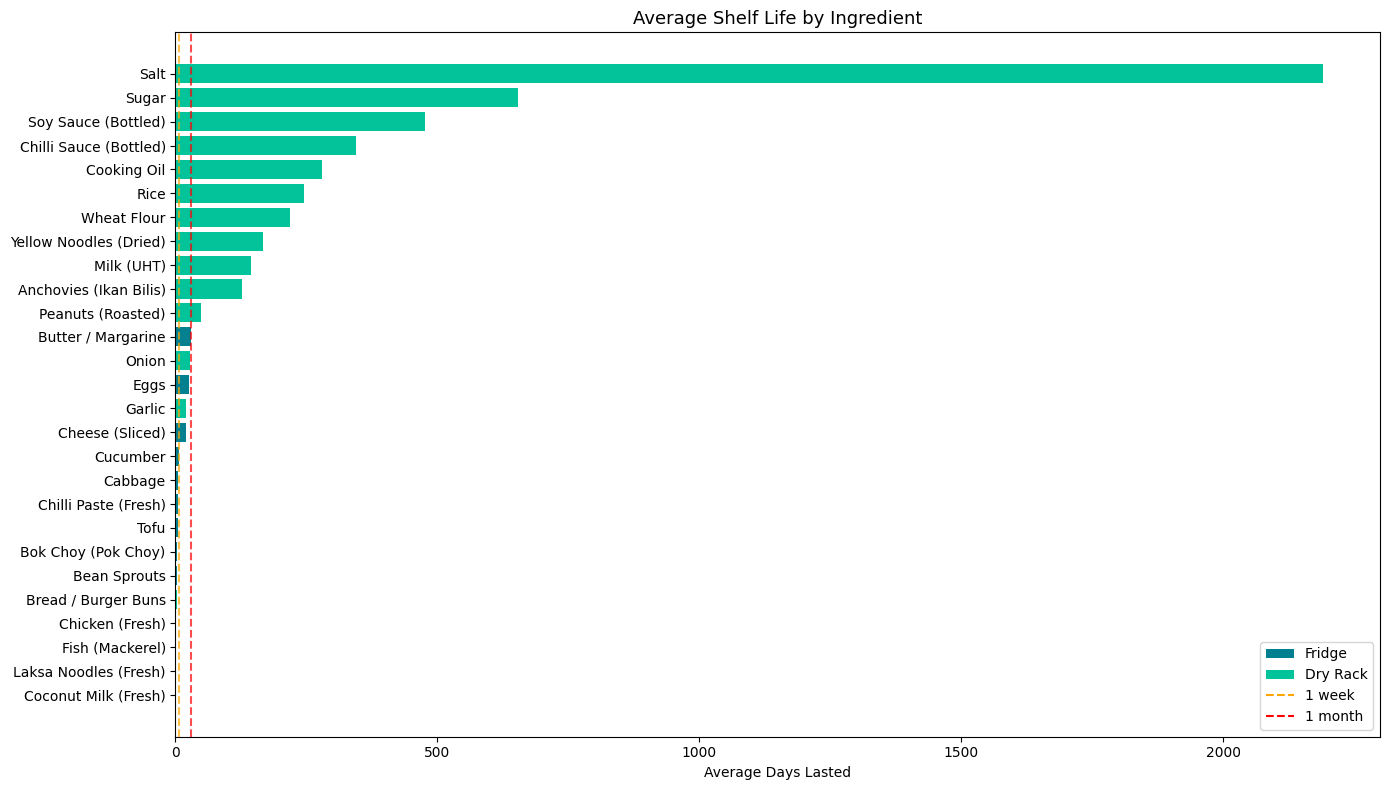

In [4]:
# Average shelf life by ingredient
avg_shelf = (df.groupby(['ingredient_name','storage_type'])['actual_days_lasted']
               .mean().round(1).reset_index()
               .sort_values('actual_days_lasted'))

plt.figure(figsize=(14, 8))
colors = {'fridge': '#028090', 'dry_rack': '#02C39A'}
bars = plt.barh(avg_shelf['ingredient_name'],
                avg_shelf['actual_days_lasted'],
                color=[colors.get(s, '#CBD5E1') for s in avg_shelf['storage_type']])
plt.xlabel('Average Days Lasted')
plt.title('Average Shelf Life by Ingredient', fontsize=13)
plt.axvline(x=7,  color='orange', linestyle='--', alpha=0.7, label='1 week')
plt.axvline(x=30, color='red',    linestyle='--', alpha=0.7, label='1 month')

# Legend for storage type
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#028090', label='Fridge'),
                   Patch(facecolor='#02C39A', label='Dry Rack'),
                   plt.Line2D([0],[0], color='orange', linestyle='--', label='1 week'),
                   plt.Line2D([0],[0], color='red',    linestyle='--', label='1 month')]
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

V2 DATA

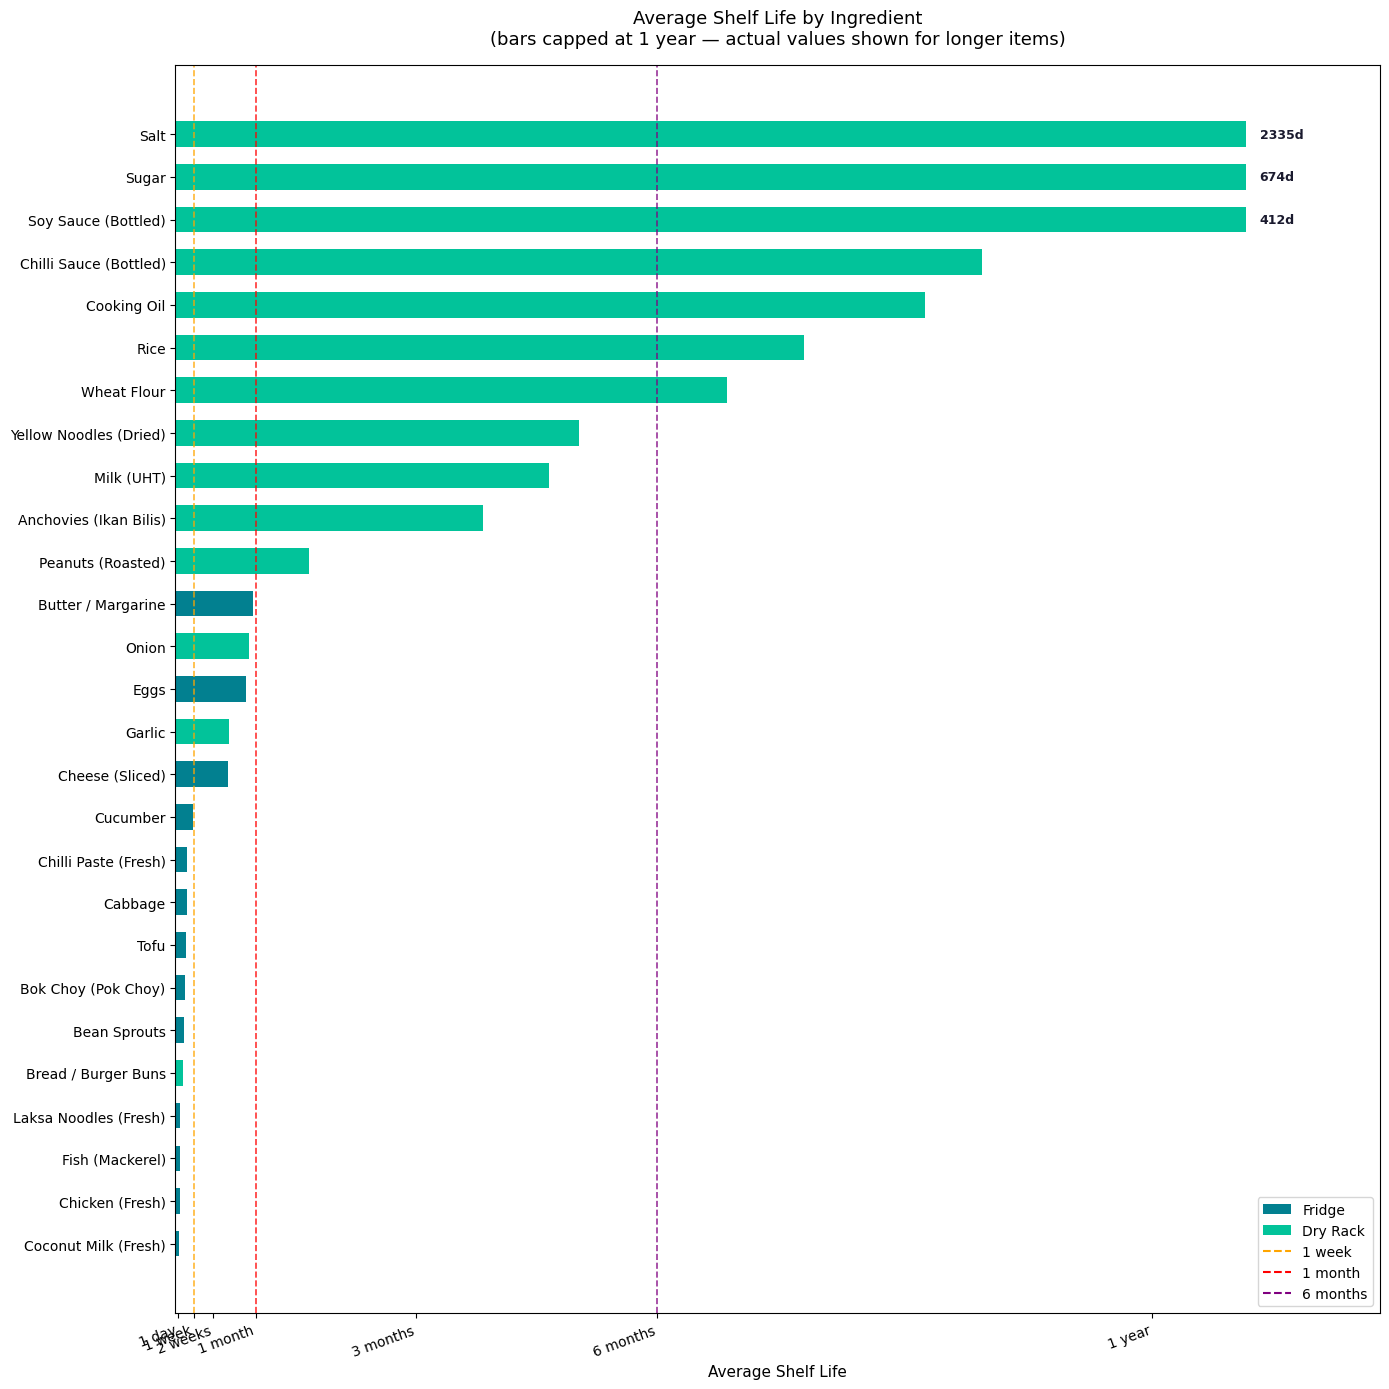

In [9]:
# Average shelf life by ingredient
avg_shelf = (df.groupby(['ingredient_name','storage_type'])['actual_days_lasted']
               .mean().round(1).reset_index()
               .sort_values('actual_days_lasted'))

fig, ax = plt.subplots(figsize=(14, 14))

colors = {'fridge': '#028090', 'dry_rack': '#02C39A'}
bars = ax.barh(avg_shelf['ingredient_name'],
               avg_shelf['actual_days_lasted'].clip(upper=400),  # cap bars at 400
               color=[colors.get(s, '#CBD5E1') for s in avg_shelf['storage_type']],
               height=0.6)

# Annotate items that exceed the cap with their real value
for i, (_, row) in enumerate(avg_shelf.iterrows()):
    if row['actual_days_lasted'] > 400:
        ax.text(405, i, f"{int(row['actual_days_lasted'])}d",
                va='center', fontsize=9, color='#1A1A2E', fontweight='bold')

# Clean readable x-axis ticks in natural time units
ax.set_xticks([1, 7, 14, 30, 90, 180, 365])
ax.set_xticklabels(['1 day', '1 week', '2 weeks', '1 month', '3 months', '6 months', '1 year'],
                    rotation=20, ha='right', fontsize=10)

# Cap x-axis — Salt and Sugar annotated instead
ax.set_xlim(0, 450)

# Reference lines
ax.axvline(x=7,   color='orange', linestyle='--', alpha=0.8, linewidth=1.2, label='1 week')
ax.axvline(x=30,  color='red',    linestyle='--', alpha=0.8, linewidth=1.2, label='1 month')
ax.axvline(x=180, color='purple', linestyle='--', alpha=0.8, linewidth=1.2, label='6 months')

ax.set_xlabel('Average Shelf Life', fontsize=11)
ax.set_title('Average Shelf Life by Ingredient\n(bars capped at 1 year — actual values shown for longer items)',
             fontsize=13, pad=15)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#028090', label='Fridge'),
    Patch(facecolor='#02C39A', label='Dry Rack'),
    plt.Line2D([0],[0], color='orange', linestyle='--', label='1 week'),
    plt.Line2D([0],[0], color='red',    linestyle='--', label='1 month'),
    plt.Line2D([0],[0], color='purple', linestyle='--', label='6 months'),
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

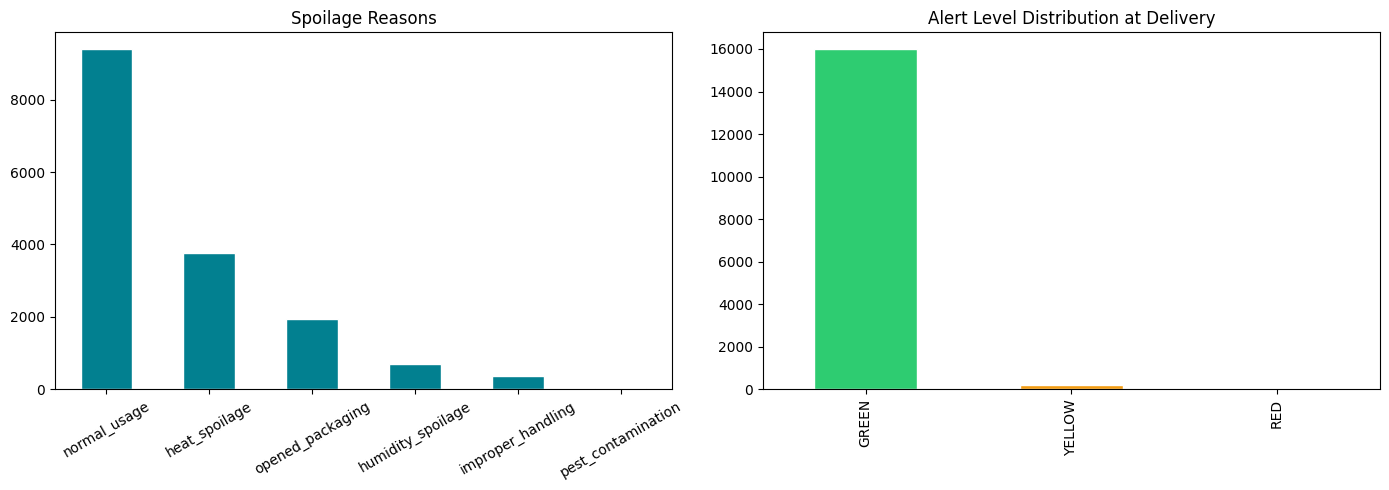

In [5]:
# Spoilage reasons breakdown
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['spoilage_reason'].value_counts().plot(
    kind='bar', ax=axes[0], color='#028090', edgecolor='white')
axes[0].set_title('Spoilage Reasons')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

df['alert_level'].value_counts().plot(
    kind='bar', ax=axes[1],
    color=['#2ECC71','#F39C12','#E74C3C'],
    edgecolor='white')
axes[1].set_title('Alert Level Distribution at Delivery')
axes[1].set_xlabel('')
plt.tight_layout()
plt.show()

V2 DATA

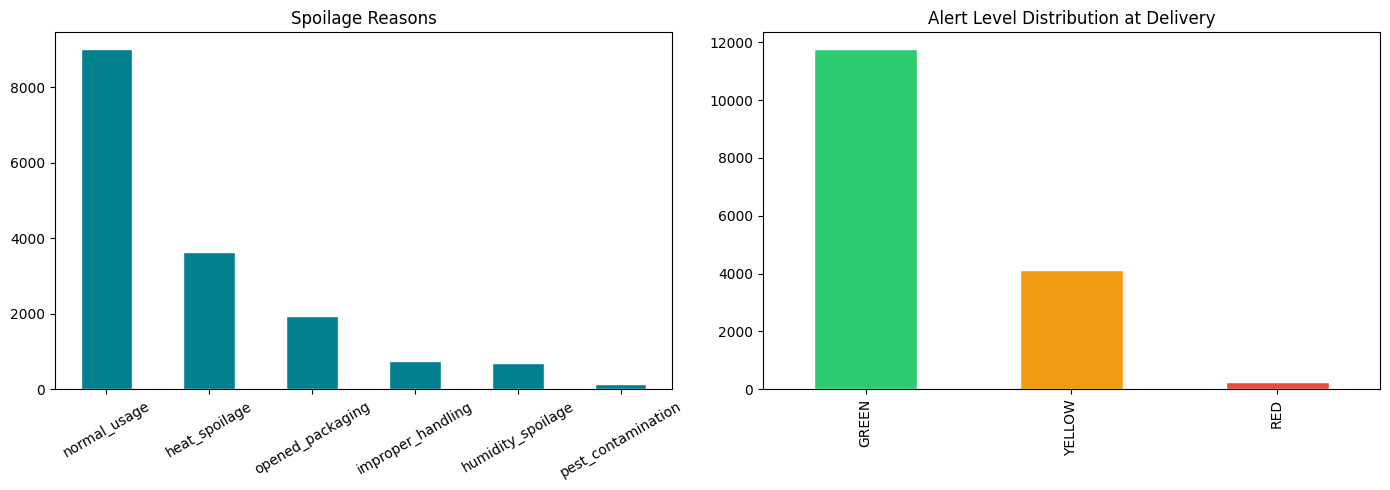

In [10]:
# Spoilage reasons breakdown
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['spoilage_reason'].value_counts().plot(
    kind='bar', ax=axes[0], color='#028090', edgecolor='white')
axes[0].set_title('Spoilage Reasons')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

df['alert_level'].value_counts().plot(
    kind='bar', ax=axes[1],
    color=['#2ECC71','#F39C12','#E74C3C'],
    edgecolor='white')
axes[1].set_title('Alert Level Distribution at Delivery')
axes[1].set_xlabel('')
plt.tight_layout()
plt.show()

In [11]:
# Weather vs shelf life for fridge items
fridge_df = df[df.storage_type == 'fridge']
weather_shelf = fridge_df.groupby('weather_on_delivery')['actual_days_lasted'].mean().round(2)
print('Average shelf life by weather (fridge items):')
print(weather_shelf)
print()
print('This shows rainy/humid weather shortens shelf life for fridge items')

Average shelf life by weather (fridge items):
weather_on_delivery
cloudy    4.24
rainy     3.99
sunny     3.97
Name: actual_days_lasted, dtype: float64

This shows rainy/humid weather shortens shelf life for fridge items


---
## STEP 4 — Prepare Features for Model Training

XGBoost can't use text — we encode everything as numbers.

In [12]:
# ── Encode categorical columns ─────────────────────────────────────────────
df_model = df.copy()

encoders = {}
cat_cols = ['ingredient_name', 'category', 'storage_type',
            'season', 'weather_on_delivery', 'purchase_frequency']

for col in cat_cols:
    le = LabelEncoder()
    df_model[col + '_enc'] = le.fit_transform(df_model[col])
    encoders[col] = le
    print(f'  {col:25s} → {len(le.classes_)} unique values')

# Save encoders for later use in FastAPI
os.makedirs('models', exist_ok=True)
joblib.dump(encoders, 'models/sle_encoders.pkl')
print('\n✅ Encoders saved to models/sle_encoders.pkl')

  ingredient_name           → 27 unique values
  category                  → 12 unique values
  storage_type              → 2 unique values
  season                    → 3 unique values
  weather_on_delivery       → 3 unique values
  purchase_frequency        → 8 unique values

✅ Encoders saved to models/sle_encoders.pkl


In [13]:
# ── Define feature set ────────────────────────────────────────────────────
FEATURES = [
    'ingredient_name_enc',    # which ingredient
    'category_enc',           # protein / vegetable / staple etc.
    'storage_type_enc',       # fridge / dry_rack
    'purchase_frequency_enc', # how often purchased
    'season_enc',             # wet / dry / transition
    'weather_on_delivery_enc',# sunny / cloudy / rainy
    'was_opened_same_day',    # 0 or 1
    'quantity_delivered',     # how much was delivered
    'delivery_month',         # seasonality within year
    'base_shelf_days',        # known baseline shelf life
]

TARGET = 'actual_days_lasted'

# ── Train / test split ────────────────────────────────────────────────────
train_df = df_model[df_model.split == 'train']
test_df  = df_model[df_model.split == 'test']

X_train = train_df[FEATURES]
y_train = train_df[TARGET]
X_test  = test_df[FEATURES]
y_test  = test_df[TARGET]

print(f'✅ Features ready!')
print(f'   Training samples : {len(X_train):,}')
print(f'   Testing samples  : {len(X_test):,}')
print(f'   Features used    : {len(FEATURES)}')

✅ Features ready!
   Training samples : 9,719
   Testing samples  : 6,421
   Features used    : 10


---
## STEP 5 — Train the SLE Model

In [14]:
# ── Train XGBoost Regressor ────────────────────────────────────────────────
# This predicts: how many days will this ingredient last?

sle_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)

print('Training SLE model...')
sle_model.fit(X_train, y_train)
print('✅ Model trained!')

Training SLE model...
✅ Model trained!


---
## STEP 6 — Evaluate the Model

In [15]:
# ── Evaluate on test set ──────────────────────────────────────────────────
y_pred = sle_model.predict(X_test)
y_pred_rounded = np.round(y_pred).clip(min=1)

mae  = mean_absolute_error(y_test, y_pred_rounded)
mape = mean_absolute_percentage_error(y_test, y_pred_rounded) * 100

print('='*50)
print('  SLE MODEL EVALUATION')
print('='*50)
print(f'  MAE  : {mae:.1f} days')
print(f'  MAPE : {mape:.1f}%')
print()
print('  HOW TO READ:')
print(f'  MAE {mae:.1f} = prediction is off by {mae:.1f} days on average')
print(f'  For a chicken with 2-day shelf life, {mae:.1f} day error is', end=' ')
print('acceptable' if mae < 1.0 else 'needs improvement')

# Evaluate separately for fridge vs dry rack
print('\n  BY STORAGE TYPE:')
for storage in ['fridge', 'dry_rack']:
    mask = test_df['storage_type'] == storage
    if mask.sum() > 0:
        mae_s = mean_absolute_error(y_test[mask], y_pred_rounded[mask])
        print(f'    {storage:10s}: MAE = {mae_s:.1f} days ({mask.sum()} samples)')

  SLE MODEL EVALUATION
  MAE  : 8.3 days
  MAPE : 29.3%

  HOW TO READ:
  MAE 8.3 = prediction is off by 8.3 days on average
  For a chicken with 2-day shelf life, 8.3 day error is needs improvement

  BY STORAGE TYPE:
    fridge    : MAE = 0.9 days (5167 samples)
    dry_rack  : MAE = 38.8 days (1254 samples)


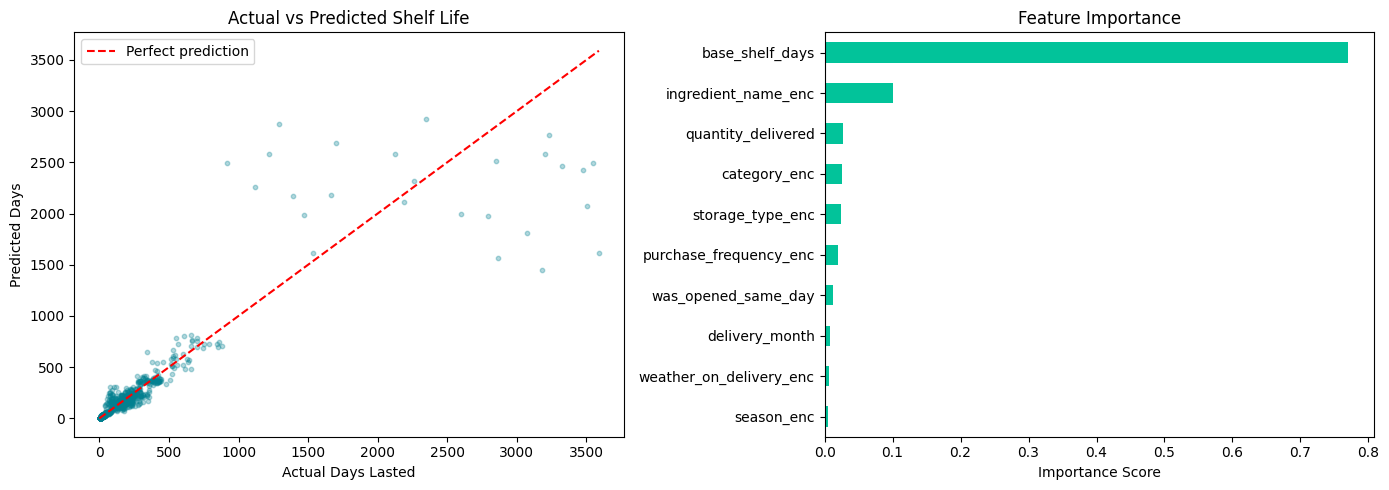

✅ Chart saved to models/sle_accuracy.png


In [16]:
# ── Plot actual vs predicted ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: actual vs predicted
axes[0].scatter(y_test, y_pred_rounded, alpha=0.3, color='#028090', s=10)
max_val = max(y_test.max(), y_pred_rounded.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction')
axes[0].set_xlabel('Actual Days Lasted')
axes[0].set_ylabel('Predicted Days')
axes[0].set_title('Actual vs Predicted Shelf Life')
axes[0].legend()

# Feature importance
importances = pd.Series(sle_model.feature_importances_, index=FEATURES)
importances.sort_values().plot(kind='barh', ax=axes[1], color='#02C39A')
axes[1].set_title('Feature Importance')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('models/sle_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved to models/sle_accuracy.png')

---
## STEP 7 — Build the Alert Engine

Three alert types for cafe owner:
- 🔴 **RED** — expires very soon, act immediately
- 🟡 **YELLOW** — use soon, monitor closely
- 🟢 **GREEN** — sufficient shelf life remaining

In [17]:
# ── Alert + clearance recommendation engine ────────────────────────────────

# Dish → ingredient mapping (from your recipe data)
# Used to suggest which dishes to push for clearance
INGREDIENT_TO_DISHES = {
    'Chicken (Fresh)':       ['Nasi Ayam', 'Nasi Campur'],
    'Fish (Mackerel)':       ['Laksa'],
    'Eggs':                  ['Nasi Lemak', 'Toast & Eggs', 'Mee Goreng Mamak', 'Nasi Campur'],
    'Coconut Milk (Fresh)':  ['Nasi Lemak'],
    'Bean Sprouts':          ['Mee Goreng Mamak', 'Mee Goreng', 'Char Kuey Teow'],
    'Cabbage':               ['Mee Goreng Mamak', 'Mee Goreng', 'Nasi Campur'],
    'Bok Choy (Pok Choy)':   ['Nasi Campur'],
    'Laksa Noodles (Fresh)': ['Laksa'],
    'Tofu':                  ['Mee Goreng Mamak'],
    'Cucumber':              ['Nasi Lemak', 'Nasi Ayam', 'Burger / Sandwich'],
    'Chilli Paste (Fresh)':  ['Mee Goreng Mamak', 'Mee Goreng', 'Char Kuey Teow'],
    'Wheat Flour':           ['Roti Canai'],
    'Bread / Burger Buns':   ['Burger / Sandwich', 'Toast & Eggs'],
    'Cheese (Sliced)':       ['Burger / Sandwich'],
    'Butter / Margarine':    ['Roti Canai', 'Toast & Eggs'],
}

def predict_shelf_life(ingredient_name, storage_type, weather,
                        season, was_opened, quantity,
                        delivery_month, purchase_frequency,
                        category, base_shelf_days,
                        current_stock_days_remaining=None):
    """
    Predict shelf life and generate alerts.

    Parameters:
    -----------
    ingredient_name           : str
    storage_type              : 'fridge' or 'dry_rack'
    weather                   : 'sunny'/'cloudy'/'rainy'
    season                    : 'wet_season'/'dry_season'/'transition'
    was_opened                : 0 or 1
    quantity                  : float (how much delivered)
    delivery_month            : int (1-12)
    purchase_frequency        : str e.g. 'every_1_days'
    category                  : str e.g. 'protein'
    base_shelf_days           : int (known baseline shelf life)
    current_stock_days_remaining: int (optional — days left on current stock)
    """
    # Encode inputs
    enc = encoders
    def safe_encode(encoder, value):
        if value in encoder.classes_:
            return encoder.transform([value])[0]
        return 0  # default if unseen

    features = pd.DataFrame([{
        'ingredient_name_enc':    safe_encode(enc['ingredient_name'],    ingredient_name),
        'category_enc':           safe_encode(enc['category'],           category),
        'storage_type_enc':       safe_encode(enc['storage_type'],       storage_type),
        'purchase_frequency_enc': safe_encode(enc['purchase_frequency'], purchase_frequency),
        'season_enc':             safe_encode(enc['season'],             season),
        'weather_on_delivery_enc':safe_encode(enc['weather_on_delivery'],weather),
        'was_opened_same_day':    was_opened,
        'quantity_delivered':     quantity,
        'delivery_month':         delivery_month,
        'base_shelf_days':        base_shelf_days,
    }])

    predicted_days = max(1, round(float(sle_model.predict(features)[0])))

    # Use current_stock if provided, else use prediction
    days_remaining = current_stock_days_remaining if current_stock_days_remaining else predicted_days

    # Alert level
    pct = days_remaining / base_shelf_days if base_shelf_days > 0 else 0
    if pct <= 0.20:   alert = "🔴 RED"
    elif pct <= 0.40: alert = "🟡 YELLOW"
    else:             alert = "🟢 GREEN"

    # Clearance recommendation
    clearance_dishes = INGREDIENT_TO_DISHES.get(ingredient_name, [])
    if days_remaining <= 2 and clearance_dishes:
        clearance_msg = (f"⚡ CLEARANCE OPPORTUNITY: Push {', '.join(clearance_dishes)} "
                         f"today to use {ingredient_name} before it expires!")
    elif days_remaining <= 5 and clearance_dishes:
        clearance_msg = (f"💡 PLAN AHEAD: Feature {clearance_dishes[0]} as special "
                         f"this week — {ingredient_name} expires in {days_remaining} days.")
    else:
        clearance_msg = None

    # Priority instruction
    if days_remaining <= 1:
        instruction = f"⛔ USE TODAY or DISCARD — {ingredient_name} expires tonight."
    elif days_remaining <= 2:
        instruction = f"⚠️  USE WITHIN 2 DAYS — prioritise {ingredient_name} in today's prep."
    elif days_remaining <= 5:
        instruction = f"📅 USE SOON — {ingredient_name} expires in {days_remaining} days."
    else:
        instruction = f"✅ STOCK OK — {ingredient_name} has {days_remaining} days remaining."

    return {
        'ingredient':            ingredient_name,
        'predicted_days_lasted': predicted_days,
        'days_remaining':        days_remaining,
        'alert_level':           alert,
        'instruction':           instruction,
        'clearance_opportunity': clearance_msg,
        'related_dishes':        clearance_dishes,
    }

print('✅ Alert engine ready!')

✅ Alert engine ready!


In [18]:
# ── TEST the alert engine with 3 scenarios ─────────────────────────────────

test_cases = [
    # Scenario 1: Fresh chicken delivered today — rainy weather
    dict(ingredient_name='Chicken (Fresh)', storage_type='fridge',
         weather='rainy', season='wet_season', was_opened=0,
         quantity=8.0, delivery_month=11, purchase_frequency='every_1_days',
         category='protein', base_shelf_days=2),

    # Scenario 2: Coconut milk — opened same day
    dict(ingredient_name='Coconut Milk (Fresh)', storage_type='fridge',
         weather='sunny', season='dry_season', was_opened=1,
         quantity=3.0, delivery_month=7, purchase_frequency='every_1_days',
         category='dairy_alt', base_shelf_days=1),

    # Scenario 3: Rice in dry store — no urgency
    dict(ingredient_name='Rice', storage_type='dry_rack',
         weather='cloudy', season='transition', was_opened=0,
         quantity=25.0, delivery_month=3, purchase_frequency='every_10_days',
         category='staple', base_shelf_days=270),
]

for i, tc in enumerate(test_cases, 1):
    result = predict_shelf_life(**tc)
    print(f'\n=== Scenario {i}: {result["ingredient"]} ===')
    for k, v in result.items():
        if v:  print(f'  {k:25s}: {v}')


=== Scenario 1: Chicken (Fresh) ===
  ingredient               : Chicken (Fresh)
  predicted_days_lasted    : 2
  days_remaining           : 2
  alert_level              : 🟢 GREEN
  instruction              : ⚠️  USE WITHIN 2 DAYS — prioritise Chicken (Fresh) in today's prep.
  clearance_opportunity    : ⚡ CLEARANCE OPPORTUNITY: Push Nasi Ayam, Nasi Campur today to use Chicken (Fresh) before it expires!
  related_dishes           : ['Nasi Ayam', 'Nasi Campur']

=== Scenario 2: Coconut Milk (Fresh) ===
  ingredient               : Coconut Milk (Fresh)
  predicted_days_lasted    : 1
  days_remaining           : 1
  alert_level              : 🟢 GREEN
  instruction              : ⛔ USE TODAY or DISCARD — Coconut Milk (Fresh) expires tonight.
  clearance_opportunity    : ⚡ CLEARANCE OPPORTUNITY: Push Nasi Lemak today to use Coconut Milk (Fresh) before it expires!
  related_dishes           : ['Nasi Lemak']

=== Scenario 3: Rice ===
  ingredient               : Rice
  predicted_days_lasted 

---
## STEP 8 — Connect SLE to Portion Prediction

Answer the key question: **Do we have enough of this ingredient for today's predicted demand?**

In [19]:
# ── Stock sufficiency checker ──────────────────────────────────────────────
# Recipe: how much of each ingredient per portion
# (ingredient_name, kg_per_portion)

RECIPE_MAP = {
    'Nasi Lemak':    [('Rice', 0.10),   ('Eggs', 0.10),    ('Coconut Milk (Fresh)', 0.05),
                      ('Cucumber', 0.05)],
    'Roti Canai':    [('Wheat Flour', 0.067), ('Butter / Margarine', 0.007)],
    'Mee Goreng Mamak': [('Bean Sprouts', 0.04), ('Cabbage', 0.04),
                          ('Tofu', 0.04), ('Eggs', 0.10),
                          ('Chilli Paste (Fresh)', 0.018)],
    'Toast & Eggs':  [('Bread / Burger Buns', 0.10), ('Eggs', 0.25),
                      ('Butter / Margarine', 0.01)],
    'Nasi Campur':   [('Rice', 0.10), ('Chicken (Fresh)', 0.10),
                      ('Cabbage', 0.05), ('Eggs', 0.10)],
    'Mee Goreng':    [('Bean Sprouts', 0.04), ('Cabbage', 0.04), ('Eggs', 0.10)],
    'Nasi Ayam':     [('Rice', 0.10), ('Chicken (Fresh)', 0.188)],
    'Laksa':         [('Fish (Mackerel)', 0.083), ('Laksa Noodles (Fresh)', 0.10),
                      ('Cucumber', 0.05)],
    'Char Kuey Teow':[('Bean Sprouts', 0.05), ('Eggs', 0.25),
                      ('Chilli Paste (Fresh)', 0.008)],
    'Burger / Sandwich': [('Bread / Burger Buns', 0.10), ('Cheese (Sliced)', 0.02)],
}

def check_stock_sufficiency(dish_name, predicted_portions, current_stock):
    """
    Check if current stock covers predicted demand.

    Parameters:
    -----------
    dish_name          : str
    predicted_portions : int (from Prophet model)
    current_stock      : dict { 'ingredient_name': kg_available }

    Returns:
    --------
    List of stock status per ingredient
    """
    recipe = RECIPE_MAP.get(dish_name, [])
    results = []

    for ingredient, kg_per_portion in recipe:
        needed     = kg_per_portion * predicted_portions
        available  = current_stock.get(ingredient, 0)
        sufficient = available >= needed
        shortfall  = max(0, needed - available)

        results.append({
            'ingredient':  ingredient,
            'needed_kg':   round(needed, 3),
            'available_kg':round(available, 3),
            'sufficient':  '✅' if sufficient else '❌ REORDER',
            'shortfall_kg':round(shortfall, 3),
        })

    return results

# ── TEST: 80 portions of Nasi Lemak predicted today ───────────────────────
print('=== STOCK CHECK: 80 portions of Nasi Lemak ===')
current_inventory = {
    'Rice':                8.5,   # kg on hand
    'Eggs':                7.0,   # kg (approx)
    'Coconut Milk (Fresh)':2.5,
    'Cucumber':            3.0,
}

stock_check = check_stock_sufficiency('Nasi Lemak', 80, current_inventory)
stock_df = pd.DataFrame(stock_check)
print(stock_df.to_string(index=False))
print()
shortfalls = [r for r in stock_check if r['shortfall_kg'] > 0]
if shortfalls:
    print('⚠️  REORDER NEEDED:')
    for s in shortfalls:
        print(f"   {s['ingredient']}: need {s['shortfall_kg']} kg more")
else:
    print('✅ All ingredients sufficient for 80 portions!')

=== STOCK CHECK: 80 portions of Nasi Lemak ===
          ingredient  needed_kg  available_kg sufficient  shortfall_kg
                Rice        8.0           8.5          ✅           0.0
                Eggs        8.0           7.0  ❌ REORDER           1.0
Coconut Milk (Fresh)        4.0           2.5  ❌ REORDER           1.5
            Cucumber        4.0           3.0  ❌ REORDER           1.0

⚠️  REORDER NEEDED:
   Eggs: need 1.0 kg more
   Coconut Milk (Fresh): need 1.5 kg more
   Cucumber: need 1.0 kg more


---
## STEP 9 — Save the SLE Model

In [20]:
# ── Save everything ───────────────────────────────────────────────────────
joblib.dump(sle_model,  'models/sle_xgboost_model.pkl')
joblib.dump(encoders,   'models/sle_encoders.pkl')

# Save recipe map and ingredient→dish map as JSON for FastAPI
with open('models/recipe_map.json', 'w') as f:
    json.dump(RECIPE_MAP, f, indent=2)

with open('models/ingredient_to_dishes.json', 'w') as f:
    json.dump(INGREDIENT_TO_DISHES, f, indent=2)

# Save feature list so FastAPI knows what to send
model_meta = {
    'features':       FEATURES,
    'target':         TARGET,
    'model_type':     'XGBRegressor',
    'mae_days':       round(mae, 2),
    'mape_pct':       round(mape, 2),
}
with open('models/sle_model_meta.json', 'w') as f:
    json.dump(model_meta, f, indent=2)

print('✅ All SLE files saved:')
for f in os.listdir('models'):
    if 'sle' in f or 'recipe' in f or 'ingredient' in f:
        size = os.path.getsize(f'models/{f}')
        print(f'   models/{f:40s} ({size:,} bytes)')

✅ All SLE files saved:
   models/ingredient_to_dishes.json                (1,029 bytes)
   models/recipe_map.json                          (1,769 bytes)
   models/sle_accuracy.png                         (106,592 bytes)
   models/sle_encoders.pkl                         (2,407 bytes)
   models/sle_model_meta.json                      (394 bytes)
   models/sle_xgboost_model.pkl                    (1,152,988 bytes)


---
## ✅ SLE MODEL COMPLETE!

### What your models/ folder now contains:
```
models/
├── sle_xgboost_model.pkl     ← SLE prediction model
├── sle_encoders.pkl          ← text → number encoders
├── sle_model_meta.json       ← feature list + accuracy scores
├── recipe_map.json           ← dish → ingredient amounts
├── ingredient_to_dishes.json ← ingredient → which dishes use it
├── prophet_*.pkl             ← all your portion prediction models
└── model_index.json          ← portion model lookup
```

### What backend gets from your two models combined:
```
POST /predict/portions
→ { predicted_portions: 80, dish: 'Nasi Lemak' }

POST /predict/shelf-life
→ { ingredient: 'Chicken', days_remaining: 1,
    alert: '🔴 RED',
    clearance: 'Push Nasi Ayam today!' }

POST /check/stock
→ { sufficient: False,
    reorder: ['Rice needs 1.5kg more'] }
```

### 📌 For backend teammate:
- Load `sle_xgboost_model.pkl` + `sle_encoders.pkl` at startup
- Use `recipe_map.json` for stock sufficiency checks
- Use `ingredient_to_dishes.json` for clearance alerts
- All alert logic is already in the `predict_shelf_life()` function above